# F2 DOCKSTRING EDA

Exploratory analysis of DOCKSTRING docking scores for **F2** (coagulation factor II / thrombin).

- Lower (more negative) score = better predicted binding (AutoDock Vina, kcal/mol)
- Dataset: ~260k molecules × 58 targets

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, QED
from rdkit.Chem.MolStandardize import rdMolStandardize

DATASET_PATH = Path("./data/dockstring-dataset.tsv")
assert DATASET_PATH.exists(), f"Missing {DATASET_PATH}"

RNG = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 120

## Load data & isolate F2

In [2]:
df = pd.read_csv(DATASET_PATH, sep="\t")
print(f"shape: {df.shape}")
print(f"columns: {list(df.columns[:5])} ... + {len(df.columns) - 5} more")
assert "F2" in df.columns and "smiles" in df.columns

f2 = df[["inchikey", "smiles", "F2"]].rename(columns={"F2": "docking_score"}).copy()
f2.head()

shape: (260155, 60)
columns: ['inchikey', 'smiles', 'PPARD', 'ABL1', 'ADAM17'] ... + 55 more


,inchikey,smiles,docking_score
0,UMVWYQXKBPJMOF-UHFFFAOYNA-N,C1=C(C2=C(C=C1O)OC(C(C2=O)=O)C3=CC=C(C(=C3)O)O)O,-8.2
1,NGOGFTYYXHNFQH-UHFFFAOYNA-N,O=S(=O)(N1CCNCCC1)C2=CC=CC=3C2=CC=NC3,-6.8
2,BGVLELSCIHASRV-QPEQYQDCNA-N,C=1C=C2S/C(/N(CC)C2=CC1OC)=C\C(=O)C,-5.8
3,KTUFNOKKBVMGRW-RPGFEBOUNA-N,C=1(N=C(C=2C=NC=CC2)C=CN1)NC=3C=C(NC(C4=CC=C(C...,-9.7
4,LLJRXVHJOJRCSM-UHFFFAOYNA-N,C1=CC=2C(=CNC2C=C1)C=3C=CN=CC3,-6.6


## Score hygiene

Check missingness, duplicates, and basic score stats before trusting the distribution.

In [3]:
scores = f2["docking_score"]

print("rows:", len(f2))
print("missing F2 scores:", int(scores.isna().sum()))
print("duplicate inchikey:", int(f2["inchikey"].duplicated().sum()))
print("duplicate smiles:", int(f2["smiles"].duplicated().sum()))
print()
print(scores.describe())
print()
for p in [0.1, 1, 5, 10, 50, 90, 95, 99, 99.9]:
    print(f"p{p:5.1f}: {np.nanpercentile(scores, p):.2f}")

rows: 260155
missing F2 scores: 5
duplicate inchikey: 0
duplicate smiles: 7

count    260150.000000
mean         -8.178486
std           0.960756
min         -12.200000
25%          -8.800000
50%          -8.200000
75%          -7.600000
max          -4.200000
Name: docking_score, dtype: float64

p  0.1: -11.10
p  1.0: -10.40
p  5.0: -9.70
p 10.0: -9.40
p 50.0: -8.20
p 90.0: -6.90
p 95.0: -6.50
p 99.0: -5.80
p 99.9: -5.10


### SMILES standardization check

Standardize → neutralize → canonicalize on a sample to see how often SMILES change (full-table pass is deferred to modeling prep).

In [4]:
uncharger = rdMolStandardize.Uncharger()
lfc = rdMolStandardize.LargestFragmentChooser()


def standardize_smiles(smi: str):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    mol = lfc.choose(mol)
    mol = uncharger.uncharge(mol)
    return Chem.MolToSmiles(mol)


sample = f2.sample(n=min(5000, len(f2)), random_state=0).copy()
sample["smiles_std"] = sample["smiles"].map(standardize_smiles)
n_fail = int(sample["smiles_std"].isna().sum())
n_raw_dupes = int(sample["smiles"].duplicated().sum())
n_std_dupes = int(sample["smiles_std"].dropna().duplicated().sum())
print(f"standardization sample n={len(sample)}")
print(f"parse failures: {n_fail}")
print(f"duplicate raw SMILES in sample: {n_raw_dupes}")
print(f"duplicate standardized SMILES in sample: {n_std_dupes}")
print("(Full-table standardize + dedupe belongs in modeling prep.)")

[23:19:11] Running LargestFragmentChooser
[23:19:11] Fragment: COC(=O)c1ccc(/C=N/N2C(=O)CN(C(C)C)C2c2ccc(C(=O)OC)cc2)cc1
[23:19:11] New largest fragment: COC(=O)c1ccc(/C=N/N2C(=O)CN(C(C)C)C2c2ccc(C(=O)OC)cc2)cc1 (56)
[23:19:11] Running Uncharger
[23:19:11] Running LargestFragmentChooser
[23:19:11] Fragment: CC(=O)Nc1ccc(C(=O)OCc2ccc(Cl)c(Cl)c2)cc1
[23:19:11] New largest fragment: CC(=O)Nc1ccc(C(=O)OCc2ccc(Cl)c(Cl)c2)cc1 (35)
[23:19:11] Running Uncharger
[23:19:11] Running LargestFragmentChooser
[23:19:11] Fragment: N#Cc1c(NC(=O)Cc2ccccc2Br)sc2c1CCCC2
[23:19:11] New largest fragment: N#Cc1c(NC(=O)Cc2ccccc2Br)sc2c1CCCC2 (37)
[23:19:11] Running Uncharger
[23:19:11] Running LargestFragmentChooser
[23:19:11] Fragment: Fc1ccc(SCCCN2CCN(c3ncccn3)CC2)cc1
[23:19:11] New largest fragment: Fc1ccc(SCCCN2CCN(c3ncccn3)CC2)cc1 (44)
[23:19:11] Running Uncharger
[23:19:11] Running LargestFragmentChooser
[23:19:11] Fragment: CCOc1ccccc1/C=N/NC(=O)c1cccc(S(=O)(=O)N2CCOCC2)c1
[23:19:11] New largest fragme

standardization sample n=5000
parse failures: 0
duplicate raw SMILES in sample: 0
duplicate standardized SMILES in sample: 0
(Full-table standardize + dedupe belongs in modeling prep.)


[23:19:13] Running LargestFragmentChooser
[23:19:13] Fragment: c1ccc2c(c1)[nH]c1ccccc12
[23:19:13] New largest fragment: c1ccc2c(c1)[nH]c1ccccc12 (22)
[23:19:13] Running Uncharger
[23:19:13] Running LargestFragmentChooser
[23:19:13] Fragment: CC1CCN(S(=O)(=O)c2ccc(Oc3ccc([N+](=O)[O-])cc3)cc2)CC1
[23:19:13] New largest fragment: CC1CCN(S(=O)(=O)c2ccc(Oc3ccc([N+](=O)[O-])cc3)cc2)CC1 (46)
[23:19:13] Running Uncharger
[23:19:13] Running LargestFragmentChooser
[23:19:13] Fragment: COC(=O)c1ccc(C2C(Oc3ccc(OC)cc3)C(=O)N2CCc2ccc(OC)c(OC)c2)cc1
[23:19:13] New largest fragment: COC(=O)c1ccc(C2C(Oc3ccc(OC)cc3)C(=O)N2CCc2ccc(OC)c(OC)c2)cc1 (65)
[23:19:13] Running Uncharger
[23:19:13] Running LargestFragmentChooser
[23:19:13] Fragment: CN1C(=O)[C@@H]2CN(c3ccc(F)cn3)C[C@]2(c2cc(-c3cccc(C#N)c3)cs2)N=C1N
[23:19:13] New largest fragment: CN1C(=O)[C@@H]2CN(c3ccc(F)cn3)C[C@]2(c2cc(-c3cccc(C#N)c3)cs2)N=C1N (51)
[23:19:13] Running Uncharger
[23:19:13] Running LargestFragmentChooser
[23:19:13] Fragment: c1c

## Score distribution

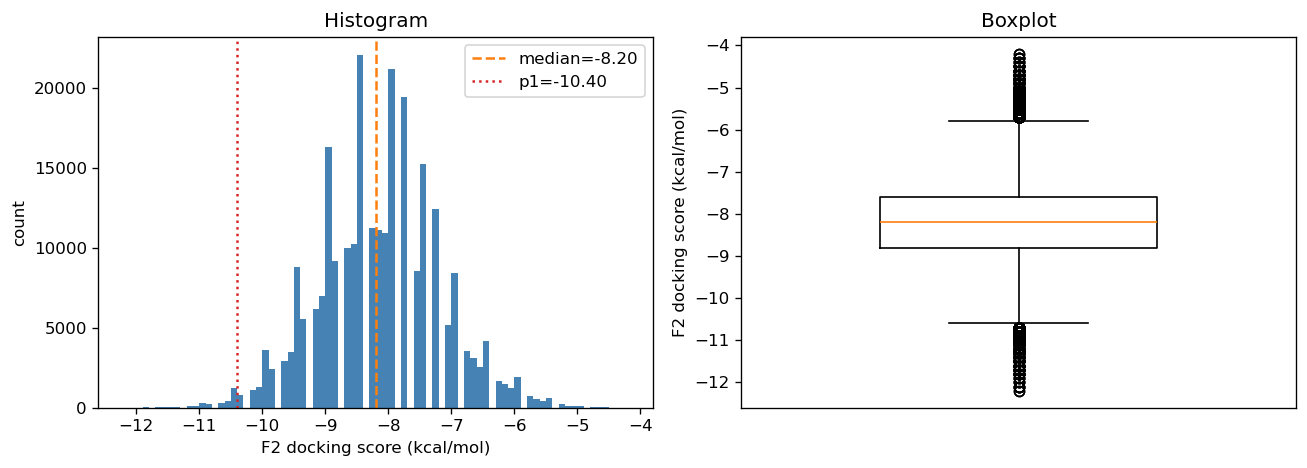

most common rounded scores:
docking_score
-8.3    11256
-8.2    11134
-8.4    11101
-8.5    10984
-8.1    10939
-8.0    10714
-7.9    10446
-8.6    10226
-7.8    10113
-8.7     9984
Name: count, dtype: int64


In [5]:
valid = scores.dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(valid, bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(valid.median(), color="C1", ls="--", label=f"median={valid.median():.2f}")
axes[0].axvline(valid.quantile(0.01), color="C3", ls=":", label=f"p1={valid.quantile(0.01):.2f}")
axes[0].set_xlabel("F2 docking score (kcal/mol)")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Histogram")

axes[1].boxplot(valid, vert=True, widths=0.5)
axes[1].set_ylabel("F2 docking score (kcal/mol)")
axes[1].set_xticks([])
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

# note clumps / discrete values
vc = valid.round(1).value_counts()
print("most common rounded scores:")
print(vc.head(10))

## Top / mid / bottom binders (structures)

Show molecules as images — not SMILES walls.

Best (most negative) F2 scores


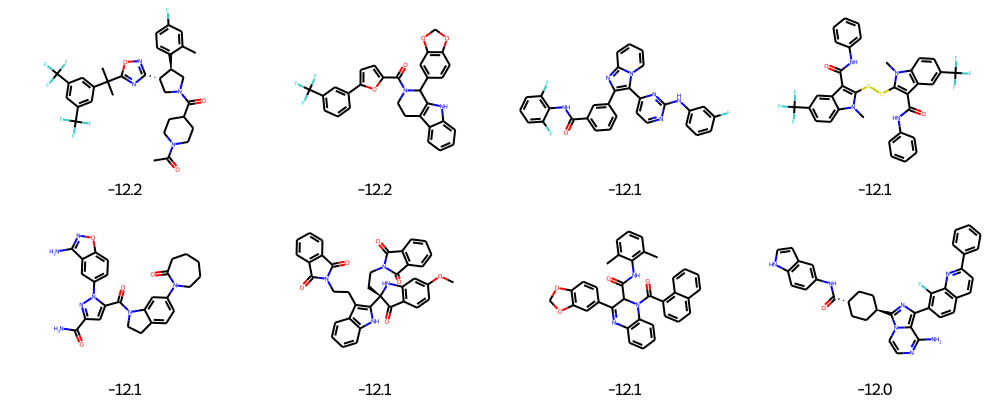

Near-median F2 scores


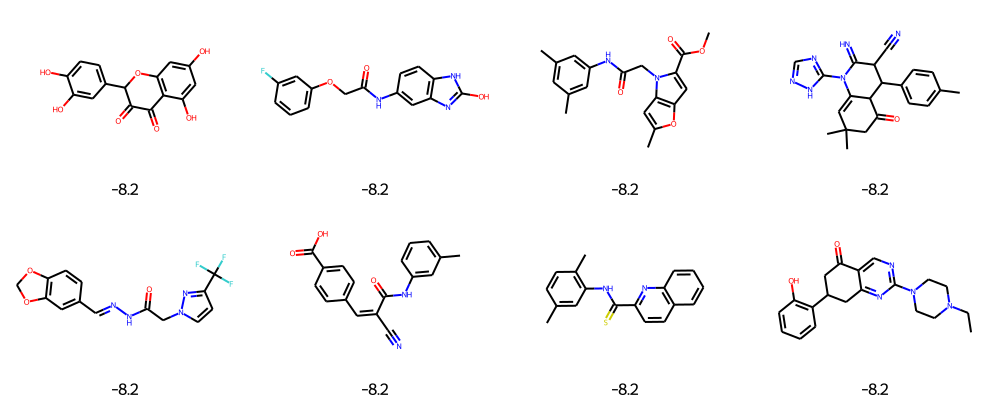

Worst (least negative / positive) F2 scores


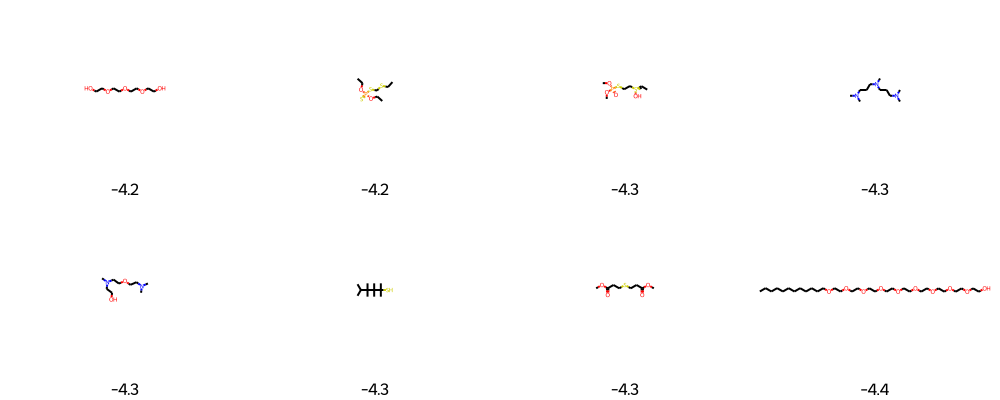

In [6]:
def mol_grid(frame: pd.DataFrame, title: str, n: int = 8):
    mols, legends = [], []
    for _, row in frame.head(n).iterrows():
        mol = Chem.MolFromSmiles(row["smiles"])
        if mol is None:
            continue
        mols.append(mol)
        legends.append(f"{row['docking_score']:.1f}")
    print(title)
    return Draw.MolsToGridImage(mols, molsPerRow=4, legends=legends, subImgSize=(250, 200))


clean = f2.dropna(subset=["docking_score"]).copy()
best = clean.nsmallest(8, "docking_score")
worst = clean.nlargest(8, "docking_score")
mid = clean.iloc[(clean["docking_score"] - clean["docking_score"].median()).abs().argsort()[:8]]

display(mol_grid(best, "Best (most negative) F2 scores"))
display(mol_grid(mid, "Near-median F2 scores"))
display(mol_grid(worst, "Worst (least negative / positive) F2 scores"))

## Score vs simple descriptors

Sample of molecules — check whether better scores mostly track size (common docking bias).

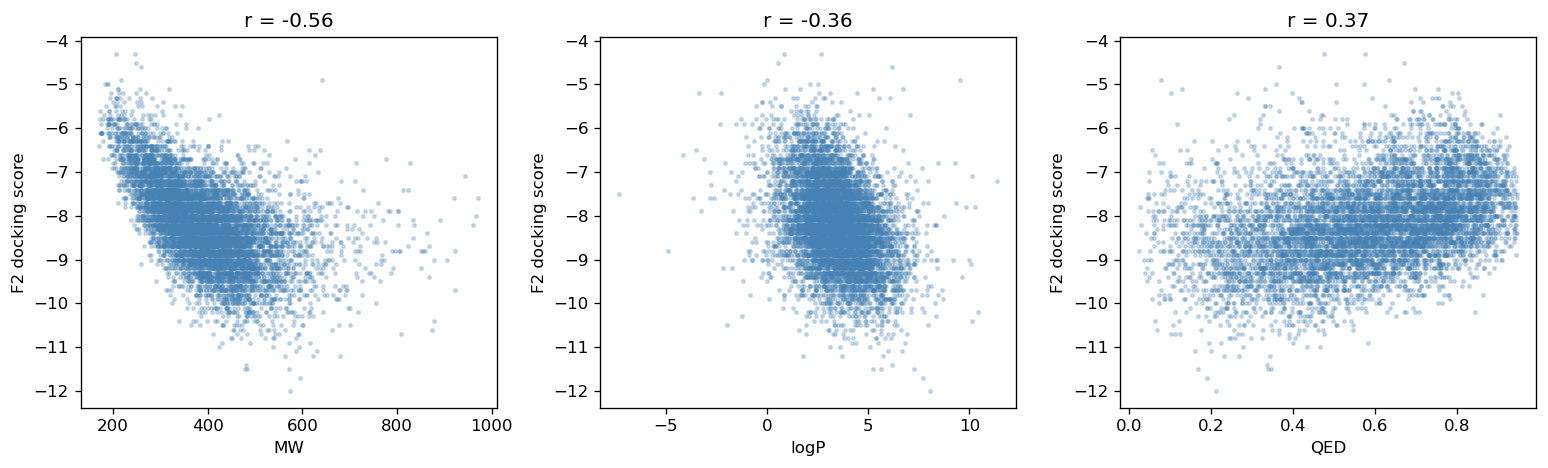

mw              -0.563390
logp            -0.357173
n_hba           -0.269166
n_hbd           -0.157562
n_rot           -0.124339
qed              0.368047
docking_score    1.000000
Name: docking_score, dtype: float64


In [7]:
def mol_props(smi: str) -> dict | None:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return {
        "mw": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "qed": QED.qed(mol),
        "n_rot": Descriptors.NumRotatableBonds(mol),
        "n_hba": Descriptors.NumHAcceptors(mol),
        "n_hbd": Descriptors.NumHDonors(mol),
    }


prop_sample = clean.sample(n=min(8000, len(clean)), random_state=0)
props = prop_sample["smiles"].map(mol_props)
prop_df = prop_sample.reset_index(drop=True).join(pd.DataFrame(props.tolist()))
prop_df = prop_df.dropna(subset=["mw"])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, x, label in zip(
    axes,
    ["mw", "logp", "qed"],
    ["MW", "logP", "QED"],
):
    ax.scatter(prop_df[x], prop_df["docking_score"], s=4, alpha=0.25, color="steelblue")
    ax.set_xlabel(label)
    ax.set_ylabel("F2 docking score")
    r = prop_df[[x, "docking_score"]].corr().iloc[0, 1]
    ax.set_title(f"r = {r:.2f}")

plt.tight_layout()
plt.show()

print(prop_df[["docking_score", "mw", "logp", "qed", "n_rot", "n_hba", "n_hbd"]].corr()["docking_score"].sort_values())

## Context for a docked molecule

Where does previously docked argatroban (−8.9 kcal/mol) sit in the F2 distribution?

reference score: -8.9
percentile (fraction of molecules with score ≤ reference): 23.95%
rank among ~260,150 molecules: about 62,293


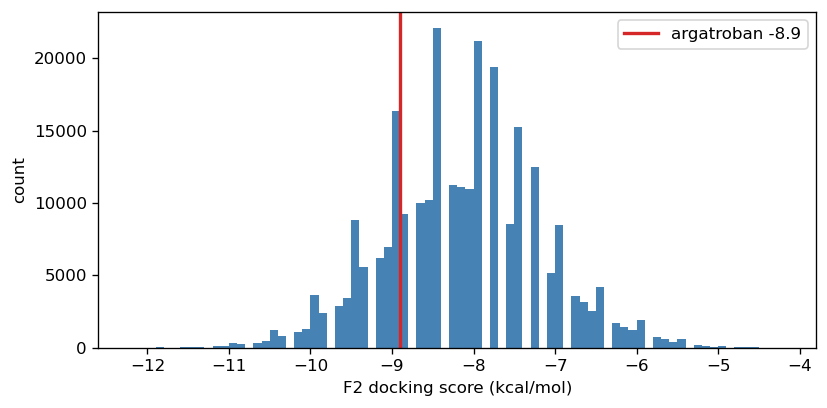

In [8]:
REFERENCE_SCORE = -8.9  # argatroban vs F2 from dock_f2.py

pct_better_or_equal = 100 * (valid <= REFERENCE_SCORE).mean()
print(f"reference score: {REFERENCE_SCORE}")
print(f"percentile (fraction of molecules with score ≤ reference): {pct_better_or_equal:.2f}%")
print(f"rank among ~{len(valid):,} molecules: about {int((valid <= REFERENCE_SCORE).sum()):,}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(valid, bins=80, color="steelblue", edgecolor="none")
ax.axvline(REFERENCE_SCORE, color="C3", lw=2, label=f"argatroban {REFERENCE_SCORE}")
ax.set_xlabel("F2 docking score (kcal/mol)")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance for F2 docking

Goal: which **Morgan fingerprint bits** and **RDKit descriptors** associate with better (more negative) F2 docking scores?

Setup (documented for reproducibility):
- Morgan fingerprints: **radius=2**, **nBits=2048**, binary
- RDKit 2D descriptors (curated set)
- Split: **ChemProp-style similarity split**, Morgan/Tanimoto **threshold=0.7**
- Model: **XGBoost** regressor on concatenated features
- Subsample for tractability (full 260k pairwise sims are too heavy in-notebook)


In [9]:
from rdkit import DataStructs
from rdkit.Chem import AllChem, rdMolDescriptors
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# --- featurization / split constants ---
MORGAN_RADIUS = 2
MORGAN_NBITS = 2048
TANIMOTO_THRESHOLD = 0.7
N_SAMPLE = 25_000  # raise toward full data later / on SAVIO
TEST_FRAC = 0.2
SEED = 0

RDKIT_DESC_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumHDonors": Descriptors.NumHDonors,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "NumAliphaticRings": Descriptors.NumAliphaticRings,
    "RingCount": Descriptors.RingCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumHeteroatoms": Descriptors.NumHeteroatoms,
    "LabuteASA": Descriptors.LabuteASA,
    "BertzCT": Descriptors.BertzCT,
    "Chi0v": Descriptors.Chi0v,
    "Chi1v": Descriptors.Chi1v,
    "Kappa1": Descriptors.Kappa1,
    "Kappa2": Descriptors.Kappa2,
    "PEOE_VSA1": Descriptors.PEOE_VSA1,
    "PEOE_VSA6": Descriptors.PEOE_VSA6,
    "SMR_VSA1": Descriptors.SMR_VSA1,
    "SMR_VSA7": Descriptors.SMR_VSA7,
    "SlogP_VSA1": Descriptors.SlogP_VSA1,
    "SlogP_VSA8": Descriptors.SlogP_VSA8,
    "EState_VSA1": Descriptors.EState_VSA1,
    "VSA_EState1": Descriptors.VSA_EState1,
    "qed": QED.qed,
    "NumAmideBonds": rdMolDescriptors.CalcNumAmideBonds,
    "NumAtomStereoCenters": rdMolDescriptors.CalcNumAtomStereoCenters,
}


In [10]:
# Reuse standardize helper if present; otherwise define it
if "standardize_smiles" not in globals():
    uncharger = rdMolStandardize.Uncharger()
    lfc = rdMolStandardize.LargestFragmentChooser()

    def standardize_smiles(smi: str):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        mol = lfc.choose(mol)
        mol = uncharger.uncharge(mol)
        return Chem.MolToSmiles(mol)


clean = f2.dropna(subset=["docking_score"]).copy()
sample = clean.sample(n=min(N_SAMPLE, len(clean)), random_state=SEED).copy()
sample["smiles_std"] = sample["smiles"].map(standardize_smiles)
sample = sample.dropna(subset=["smiles_std"]).drop_duplicates("smiles_std").reset_index(drop=True)
print(f"analysis set after standardize+dedupe: {len(sample):,}")


[23:25:42] Running LargestFragmentChooser
[23:25:42] Fragment: CN(C)Cc1ccccc1-c1ccc(-c2cnc3c(C(F)(F)F)nn(-c4ccc5onc(N)c5c4)c3c2O)cc1
[23:25:42] New largest fragment: CN(C)Cc1ccccc1-c1ccc(-c2cnc3c(C(F)(F)F)nn(-c4ccc5onc(N)c5c4)c3c2O)cc1 (63)
[23:25:42] Running Uncharger
[23:25:42] Running LargestFragmentChooser
[23:25:42] Fragment: O=C(Cc1coc2ccc3ccccc3c12)Nc1nnc(C2CC2)s1
[23:25:42] New largest fragment: O=C(Cc1coc2ccc3ccccc3c12)Nc1nnc(C2CC2)s1 (40)
[23:25:42] Running Uncharger
[23:25:42] Running LargestFragmentChooser
[23:25:42] Fragment: Brc1cccc(-c2nn(-c3ccccc3)c3c2cnc2cc4c(cc23)OCO4)c1
[23:25:42] New largest fragment: Brc1cccc(-c2nn(-c3ccccc3)c3c2cnc2cc4c(cc23)OCO4)c1 (43)
[23:25:42] Running Uncharger
[23:25:42] Running LargestFragmentChooser
[23:25:42] Fragment: COC(=O)c1c(OCCN2CCOCC2)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1C3=O
[23:25:42] New largest fragment: COC(=O)c1c(OCCN2CCOCC2)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1C3=O (59)
[23:25:42] Running Uncharger
[23:25:42] Running LargestFragmentCh

analysis set after standardize+dedupe: 24,998


[23:25:56] Fragment: COC(=O)c1cc2oc3ccccc3c2n1CC(=O)Nc1ccc(C)cc1C
[23:25:56] New largest fragment: COC(=O)c1cc2oc3ccccc3c2n1CC(=O)Nc1ccc(C)cc1C (48)
[23:25:56] Running Uncharger
[23:25:56] Running LargestFragmentChooser
[23:25:56] Fragment: NC1(Cc2ccc3ccccc3c2)CCN(c2ncnc3[nH]ccc23)CC1
[23:25:56] New largest fragment: NC1(Cc2ccc3ccccc3c2)CCN(c2ncnc3[nH]ccc23)CC1 (50)
[23:25:56] Running Uncharger
[23:25:56] Running LargestFragmentChooser
[23:25:56] Fragment: C[C@H]1CN([C@@H](C)CO)C(=O)CCCn2nncc2CO[C@@H]1CN(C)S(=O)(=O)c1cccc(C#N)c1
[23:25:56] New largest fragment: C[C@H]1CN([C@@H](C)CO)C(=O)CCCn2nncc2CO[C@@H]1CN(C)S(=O)(=O)c1cccc(C#N)c1 (67)
[23:25:56] Running Uncharger
[23:25:56] Running LargestFragmentChooser
[23:25:56] Fragment: O=C(Nc1cccc(CCN2CCN(c3ccccc3)CC2)c1)Nc1ccccn1
[23:25:56] New largest fragment: O=C(Nc1cccc(CCN2CCN(c3ccccc3)CC2)c1)Nc1ccccn1 (57)
[23:25:56] Running Uncharger
[23:25:56] Running LargestFragmentChooser
[23:25:56] Fragment: COc1ccc2[nH]cc(CCn3c(O)ccc3O)c2c1
[23:2

In [11]:
def morgan_fp(smi: str):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, MORGAN_RADIUS, nBits=MORGAN_NBITS)


def rdkit_desc_row(smi: str):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    out = {}
    for name, fn in RDKIT_DESC_FUNCS.items():
        try:
            out[name] = float(fn(mol))
        except Exception:
            out[name] = np.nan
    return out


fps = [morgan_fp(s) for s in sample["smiles_std"]]
ok = [fp is not None for fp in fps]
sample = sample.loc[ok].reset_index(drop=True)
fps = [fp for fp, keep in zip(fps, ok) if keep]

desc_df = pd.DataFrame([rdkit_desc_row(s) for s in sample["smiles_std"]])
desc_df = desc_df.dropna(axis=1, how="any")
desc_df = desc_df.loc[:, desc_df.nunique() > 1]
print(f"molecules: {len(sample):,}")
print(f"RDKit descriptors kept: {desc_df.shape[1]}")
print(f"Morgan bits: {MORGAN_NBITS} (radius={MORGAN_RADIUS})")


molecules: 24,998
RDKit descriptors kept: 29
Morgan bits: 2048 (radius=2)


### Similarity split (Tanimoto ≥ 0.7 stays with train)

Train is a random majority slice. Remaining molecules enter **test only if** their max Morgan/Tanimoto similarity to train is **< 0.7**; otherwise they stay in train to avoid near-duplicate leakage.


In [12]:
def similarity_split(fps, test_frac=0.2, threshold=0.7, seed=0):
    """ChemProp-style fingerprint similarity split."""
    rng = np.random.default_rng(seed)
    n = len(fps)
    order = rng.permutation(n).tolist()
    n_train_target = int(round(n * (1.0 - test_frac)))

    train = order[:n_train_target]
    remain = order[n_train_target:]
    train_fps = [fps[i] for i in train]

    test, extra_train = [], []
    for i in remain:
        max_sim = max(DataStructs.BulkTanimotoSimilarity(fps[i], train_fps))
        if max_sim < threshold:
            test.append(i)
        else:
            extra_train.append(i)
    train = train + extra_train
    return np.array(train), np.array(test)


train_idx, test_idx = similarity_split(
    fps, test_frac=TEST_FRAC, threshold=TANIMOTO_THRESHOLD, seed=SEED
)
print(
    f"split: train={len(train_idx):,}  test={len(test_idx):,}  "
    f"(requested test_frac={TEST_FRAC}, threshold={TANIMOTO_THRESHOLD})"
)
if len(test_idx) == 0:
    raise RuntimeError("Empty test set — lower threshold or change sample/seed")

check_n = min(200, len(test_idx))
train_fps = [fps[i] for i in train_idx]
max_sims = [
    max(DataStructs.BulkTanimotoSimilarity(fps[i], train_fps))
    for i in test_idx[:check_n]
]
print(
    f"max Tanimoto(test→train) on {check_n} test mols: "
    f"max={np.max(max_sims):.3f}, mean={np.mean(max_sims):.3f} "
    f"(should be < {TANIMOTO_THRESHOLD})"
)


split: train=20,816  test=4,182  (requested test_frac=0.2, threshold=0.7)
max Tanimoto(test→train) on 200 test mols: max=0.821, mean=0.511 (should be < 0.7)


In [13]:
X_fp = np.zeros((len(fps), MORGAN_NBITS), dtype=np.float32)
for i, fp in enumerate(fps):
    on_bits = list(fp.GetOnBits())
    if on_bits:
        X_fp[i, on_bits] = 1.0

X_desc = desc_df.to_numpy(dtype=np.float32)
desc_names = list(desc_df.columns)
fp_names = [f"morgan_{b}" for b in range(MORGAN_NBITS)]
feature_names = fp_names + desc_names

X = np.hstack([X_fp, X_desc])
y = sample["docking_score"].to_numpy(dtype=np.float32)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print("X_train", X_train.shape, "X_test", X_test.shape)


X_train (20816, 2077) X_test (4182, 2077)


In [14]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
)
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)
print(
    "train R2:", round(r2_score(y_train, pred_train), 3),
    "MAE:", round(mean_absolute_error(y_train, pred_train), 3),
)
print(
    "test  R2:", round(r2_score(y_test, pred_test), 3),
    "MAE:", round(mean_absolute_error(y_test, pred_test), 3),
)
print(
    f"(split=Morgan/Tanimoto similarity, threshold={TANIMOTO_THRESHOLD}, "
    f"radius={MORGAN_RADIUS}, nBits={MORGAN_NBITS})"
)


train R2: 0.877 MAE: 0.265
test  R2: 0.809 MAE: 0.33
(split=Morgan/Tanimoto similarity, threshold=0.7, radius=2, nBits=2048)


### Which features matter?

XGBoost **gain** importance ranks influence (not direction). For descriptors we also show **Spearman correlation** with F2 score: **negative r ⇒ associated with better (more negative) docking**.


Top RDKit descriptors by XGBoost gain (with Spearman vs F2 score):


,feature,spearman_r,pvalue,gain
13,BertzCT,-0.7320,0.0,0.0627
9,RingCount,-0.7047,0.0,0.0236
1,HeavyAtomCount,-0.6666,0.0,0.0187
21,SMR_VSA7,-0.5758,0.0,0.0041
27,NumAmideBonds,-0.2232,0.0,0.0040
6,NumRotatableBonds,-0.1820,0.0,0.0030
8,NumAliphaticRings,-0.2110,0.0,0.0021
24,EState_VSA1,-0.1531,0.0,0.0016
3,NumHDonors,-0.1379,0.0,0.0013
23,SlogP_VSA8,-0.2854,0.0,0.0011


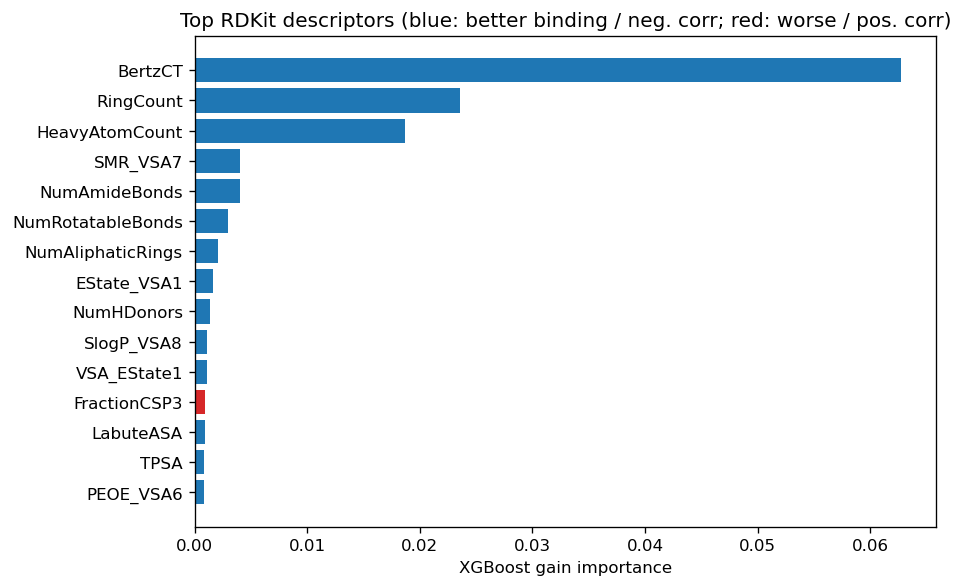

In [15]:
imp = pd.Series(model.feature_importances_, index=feature_names, name="gain")
imp_fp = imp[fp_names].sort_values(ascending=False)

desc_corr = []
for name in desc_names:
    r, p = spearmanr(desc_df[name], sample["docking_score"])
    desc_corr.append({"feature": name, "spearman_r": r, "pvalue": p, "gain": float(imp[name])})
desc_corr = pd.DataFrame(desc_corr).sort_values("gain", ascending=False)

print("Top RDKit descriptors by XGBoost gain (with Spearman vs F2 score):")
display(desc_corr.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 5))
top = desc_corr.head(15).iloc[::-1]
colors = ["C3" if r > 0 else "C0" for r in top["spearman_r"]]
ax.barh(top["feature"], top["gain"], color=colors)
ax.set_xlabel("XGBoost gain importance")
ax.set_title("Top RDKit descriptors (blue: better binding / neg. corr; red: worse / pos. corr)")
plt.tight_layout()
plt.show()


Top Morgan bits (negative delta ⇒ bit present associates with better F2 docking):


,bit,gain,frac_on,mean_score_delta_on_minus_off
0,1911,0.0057,0.0927,0.3301
1,695,0.0053,0.4340,0.1075
2,841,0.0037,0.2309,0.0954
3,338,0.0033,0.0232,-0.7641
4,926,0.0033,0.5075,-0.3424
5,1699,0.0032,0.0129,0.1047
6,249,0.0031,0.1108,0.1078
7,1816,0.0031,0.2193,-0.3044
8,294,0.0031,0.1888,0.3714
9,875,0.0029,0.5375,-0.4442


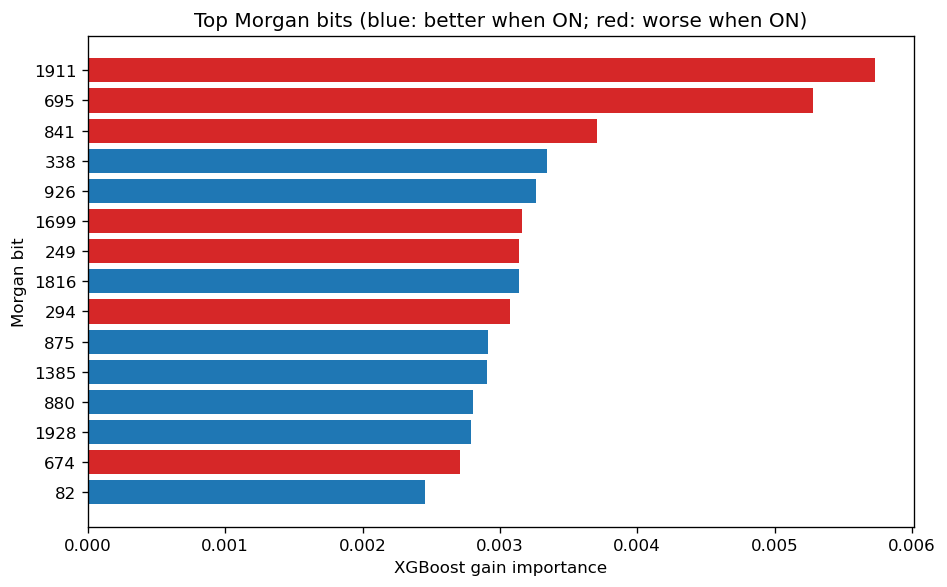

In [16]:
bit_rows = []
for name, gain in imp_fp.head(30).items():
    b = int(name.split("_")[1])
    on = X_fp[:, b] > 0
    if on.sum() < 20 or (~on).sum() < 20:
        continue
    delta = float(y[on].mean() - y[~on].mean())  # neg => bit ON associates with better scores
    bit_rows.append(
        {
            "bit": b,
            "gain": float(gain),
            "frac_on": float(on.mean()),
            "mean_score_delta_on_minus_off": delta,
        }
    )

bit_df = pd.DataFrame(bit_rows).sort_values("gain", ascending=False)
print("Top Morgan bits (negative delta ⇒ bit present associates with better F2 docking):")
display(bit_df.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = bit_df.head(15).iloc[::-1]
colors = ["C3" if d > 0 else "C0" for d in plot_df["mean_score_delta_on_minus_off"]]
ax.barh(plot_df["bit"].astype(str), plot_df["gain"], color=colors)
ax.set_xlabel("XGBoost gain importance")
ax.set_ylabel("Morgan bit")
ax.set_title("Top Morgan bits (blue: better when ON; red: worse when ON)")
plt.tight_layout()
plt.show()


Example substructures for bits associated with better binding:


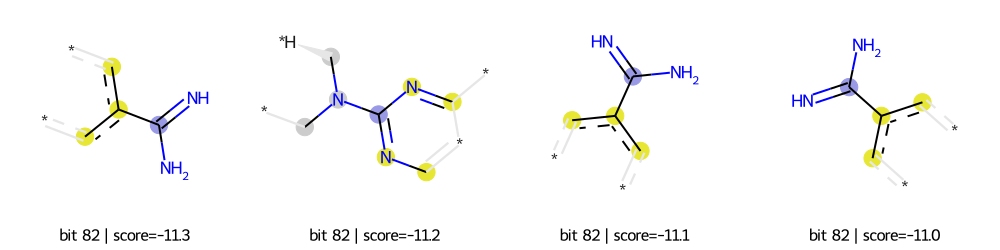

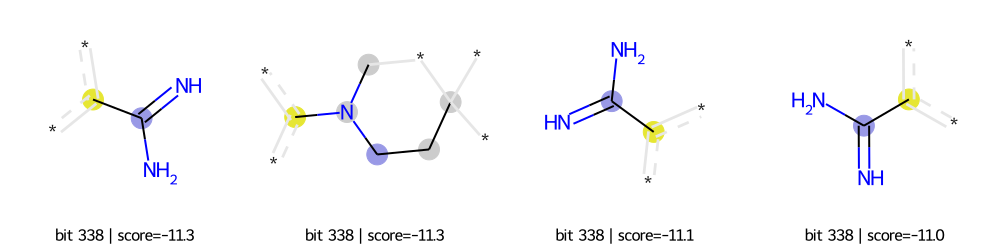

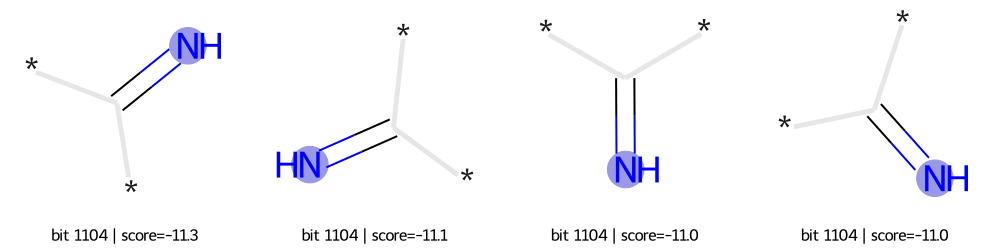

In [17]:
def draw_bit_examples(bit: int, n: int = 4):
    hits = [i for i, fp in enumerate(fps) if fp.GetBit(bit)]
    if not hits:
        print(f"bit {bit}: no hits")
        return None
    hits = sorted(hits, key=lambda i: y[i])[:n]
    mols, legends, infos = [], [], []
    for i in hits:
        mol = Chem.MolFromSmiles(sample.loc[i, "smiles_std"])
        info = {}
        AllChem.GetMorganFingerprintAsBitVect(
            mol, MORGAN_RADIUS, nBits=MORGAN_NBITS, bitInfo=info
        )
        mols.append(mol)
        legends.append(f"bit {bit} | score={y[i]:.1f}")
        infos.append(info)
    return Draw.DrawMorganBits(
        [(mols[k], bit, infos[k]) for k in range(len(mols))],
        molsPerRow=4,
        legends=legends,
        subImgSize=(250, 250),
    )


top_better_bits = (
    bit_df.sort_values("mean_score_delta_on_minus_off").head(3)["bit"].tolist()
)
print("Example substructures for bits associated with better binding:")
for b in top_better_bits:
    img = draw_bit_examples(int(b))
    if img is not None:
        display(img)


### How to read this

- We are predicting a **docking proxy** for affinity, not experimental potency.
- Importance ≠ causation; correlated descriptors (e.g. MW / LabuteASA / BertzCT) often share credit.
- Similarity split (Tanimoto 0.7) makes test metrics more honest than a random split.
- Raise `N_SAMPLE` (or move this block to a script on SAVIO) for a stabler ranking.


## Takeaways (fill in after running)

- Score scale / typical range:
- Missingness / duplicates / SMILES hygiene:
- Oddities (clumps, outliers):
- Correlation with size / lipophilicity:
- What “strong” means for F2 (e.g. top 1% threshold):
- Top descriptors linked to better F2 docking:
- Top Morgan bits / substructures linked to better F2 docking:

**Next (modeling):** optionally retrain on a larger sample / full data with the same Morgan radius=2, nBits=2048 + RDKit descriptors and Tanimoto-0.7 similarity split.
